### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [2]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

## Create a flow of messages including AIMessage and HumanMessage
messages = [AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content = f"I want to learn coding",name="Dhruv"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Dhruv"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Dhruv

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Dhruv

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-120b")
result = llm.invoke(messages)

## Print the response metadata
result.response_metadata

{'token_usage': {'completion_tokens': 2823,
  'prompt_tokens': 113,
  'total_tokens': 2936,
  'completion_time': 5.946571452,
  'completion_tokens_details': {'reasoning_tokens': 26},
  'prompt_time': 0.004509009,
  'prompt_tokens_details': None,
  'queue_time': 0.306350698,
  'total_time': 5.951080461},
 'model_name': 'openai/gpt-oss-120b',
 'system_fingerprint': 'fp_5a93aea882',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [5]:
## Create a simple tool
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [ ]:
## Binding tool with llm
llm_with_tools = llm.bind_tools([add])

## Invoke the combined LLM
llm_with_tools.invoke([HumanMessage(content = f"What is 2 plus 2", name = "Dhruv")])

AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'User asks simple math: 2+2 = 4. No need for tool.'}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 148, 'total_tokens': 186, 'completion_time': 0.079369853, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.005981196, 'prompt_tokens_details': None, 'queue_time': 0.443928886, 'total_time': 0.085351049}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a3f0-96c6-7f93-8919-e4d75592bec2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 148, 'output_tokens': 38, 'total_tokens': 186, 'output_token_details': {'reasoning': 19}})

In [ ]:
tool_call = llm_with_tools.invoke([HumanMessage(content = f"What is 2 plus 2", name = "Dhruv")])

## Not giving the desired output
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'fc_88bcfe71-73c8-4fac-98c9-2d828140a368',
  'type': 'tool_call'}]

### Using messages as state

In [9]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

#### Reducers

Each node will return a new value for our state key messages. But, this new value will override the prior messages value. As our graph runs, we want to append messages to our messages state key. We can use reducer functions to address this. Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before. But, to append messages, we can use the pre-built add_messages reducer. This ensures that any messages are appended to the existing list of messages. We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [ ]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

### Reducers with add_messages

In [11]:
initial_messages = [AIMessage(content = f"Please tell me how can I help", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name="Dhruv"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Dhruv')]

In [12]:
ai_message = AIMessage(content = f"Which programming language you want to learn",name="LLMModel")

## Reducers add_messages is to append instead of override
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='3907e82c-2567-4eb0-8c8c-f0045e9698de', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Dhruv', id='fb0ee5cf-17de-48eb-805c-e7f26ba7c1b4'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='608c0643-d425-4ee6-87a7-4a3c074702ee', tool_calls=[], invalid_tool_calls=[])]

In [13]:
## chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

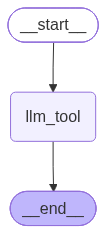

In [14]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## Build the graph
builder = StateGraph(State)

## Add Node
builder.add_node("llm_tool",llm_tool)

## Add Edges
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
## invocation
messages = graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (fc_0bbd4556-2e9c-46f8-aeba-1ae7cf41e3c5)
 Call ID: fc_0bbd4556-2e9c-46f8-aeba-1ae7cf41e3c5
  Args:
    a: 2
    b: 2


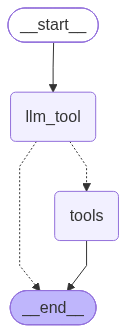

In [17]:
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)

## Add nodes
builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode([add]))

## Add edges
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    ## If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

## Compile the graph
graph_builder = builder.compile()

## View the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [18]:
## invocation
messages = graph_builder.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================

2 + 2 = 4.


In [19]:
messages = graph_builder.invoke({"messages":"What Machine Learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What Machine Learning
================================== Ai Message ==================================

**Machine Learning (ML)** is a sub‑field of artificial intelligence that focuses on building systems that can **learn from data** and improve their performance on a task without being explicitly programmed for every possible scenario.

---

## Core Idea
- **Data + Algorithm → Model**  
  You feed a computer a large set of examples (the data). An algorithm processes those examples and produces a **model**—a mathematical representation that captures patterns in the data.  
- **Prediction/Decision**  
  Once trained, the model can make predictions on new, unseen inputs (e.g., classify an email as spam or predict tomorrow’s temperature).

---

## Main Types of Machine Learning

| Category | How It Works | Typical Tasks | Example Algorithms |
|----------|--------------|---------------|--------------------|
|